# Stock Price Prediction Problem

## Loading and Handling Data into Pandas

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [14]:
data = pd.read_csv('sp500_stocks.csv')
print(data.head)

<bound method NDFrame.head of                Date Symbol   Adj Close       Close        High         Low  \
0        2010-01-04    MMM   40.835041   69.414719   69.774246   69.122070   
1        2010-01-05    MMM   40.579273   68.979935   69.590302   68.311035   
2        2010-01-06    MMM   41.154758   69.958191   70.735786   69.824417   
3        2010-01-07    MMM   41.184265   70.008362   70.033447   68.662209   
4        2010-01-08    MMM   41.474476   70.501671   70.501671   69.648827   
...             ...    ...         ...         ...         ...         ...   
1809789  2024-04-15    ZTS  149.770004  149.770004  155.000000  149.240005   
1809790  2024-04-16    ZTS  153.020004  153.020004  154.399994  148.660004   
1809791  2024-04-17    ZTS  151.940002  151.940002  153.179993  151.240005   
1809792  2024-04-18    ZTS  153.110001  153.110001  153.669998  151.169998   
1809793  2024-04-19    ZTS  146.500000  146.500000  151.539993  145.800003   

               Open     Volume  


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809794 entries, 0 to 1809793
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 110.5+ MB


In [16]:
data.describe()

,Adj Close,Close,High,Low,Open,Volume
count,1.719117e+06,1.719117e+06,1.719117e+06,1.719117e+06,1.719117e+06,1.719117e+06
mean,9.671863e+01,1.037284e+02,1.048687e+02,1.025313e+02,1.037090e+02,5.904061e+06
std,2.002185e+02,2.002123e+02,2.025636e+02,1.977921e+02,2.001391e+02,1.983689e+07
min,7.000000e-01,7.000000e-01,7.100000e-01,6.500000e-01,7.000000e-01,0.000000e+00
25%,2.943000e+01,3.519000e+01,3.559000e+01,3.478779e+01,3.519000e+01,9.868000e+05
50%,5.386000e+01,6.222000e+01,6.285000e+01,6.154000e+01,6.220000e+01,2.133800e+06
75%,1.028385e+02,1.120700e+02,1.132400e+02,1.108600e+02,1.120500e+02,4.883800e+06
max,8.099960e+03,8.099960e+03,8.211400e+03,8.010000e+03,8.097980e+03,1.880998e+09


# Data Cleaning

In [17]:
data.isnull().sum()

Date             0
Symbol           0
Adj Close    90677
Close        90677
High         90677
Low          90677
Open         90677
Volume       90677
dtype: int64

In [18]:
data.fillna(0, inplace=True)

In [19]:
data.isnull().sum()

Date         0
Symbol       0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [20]:
data.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,40.835041,69.414719,69.774246,69.122070,69.473244,3640265.0
1,2010-01-05,MMM,40.579273,68.979935,69.590302,68.311035,69.230766,3405012.0
2,2010-01-06,MMM,41.154758,69.958191,70.735786,69.824417,70.133781,6301126.0
3,2010-01-07,MMM,41.184265,70.008362,70.033447,68.662209,69.665550,5346240.0
4,2010-01-08,MMM,41.474476,70.501671,70.501671,69.648827,69.974915,4073337.0


# Convert the date column to datetime format:

In [21]:
from datetime import datetime

# Define a lambda function for parsing dates
dateparse = lambda dates: datetime.strptime(dates, '%Y-%m-%d')

# Read the CSV file, specifying the 'date' column to parse as dates
data = pd.read_csv('sp500_stocks.csv', parse_dates=['Date'], index_col='Date', date_parser=dateparse)

# Display the first few rows of the DataFrame
print(data.head())


C:\Users\mohit\AppData\Local\Temp\ipykernel_23080\3407067169.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = pd.read_csv('sp500_stocks.csv', parse_dates=['Date'], index_col='Date', date_parser=dateparse)


           Symbol  Adj Close      Close       High        Low       Open  \
Date                                                                       
2010-01-04    MMM  40.835041  69.414719  69.774246  69.122070  69.473244   
2010-01-05    MMM  40.579273  68.979935  69.590302  68.311035  69.230766   
2010-01-06    MMM  41.154758  69.958191  70.735786  69.824417  70.133781   
2010-01-07    MMM  41.184265  70.008362  70.033447  68.662209  69.665550   
2010-01-08    MMM  41.474476  70.501671  70.501671  69.648827  69.974915   

               Volume  
Date                   
2010-01-04  3640265.0  
2010-01-05  3405012.0  
2010-01-06  6301126.0  
2010-01-07  5346240.0  
2010-01-08  4073337.0  


In [22]:
#check datatype of index
data.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2024-04-08', '2024-04-09', '2024-04-10', '2024-04-11',
               '2024-04-12', '2024-04-15', '2024-04-16', '2024-04-17',
               '2024-04-18', '2024-04-19'],
              dtype='datetime64[ns]', name='Date', length=1809794, freq=None)

# Convert the data to time series:

In [23]:
#convert to time series:
ts = data['Adj Close']
ts.head(10)

Date
2010-01-04    40.835041
2010-01-05    40.579273
2010-01-06    41.154758
2010-01-07    41.184265
2010-01-08    41.474476
2010-01-11    41.307240
2010-01-12    41.341663
2010-01-13    41.208862
2010-01-14    41.071140
2010-01-15    41.007202
Name: Adj Close, dtype: float64

### Indexing TS arrays:

In [24]:
#1. Specific the index as a string constant:
ts['2024-04-18']

Date
2024-04-18     91.480003
2024-04-18     86.690002
2024-04-18    105.269997
2024-04-18    164.660004
2024-04-18    316.000000
                 ...    
2024-04-18    127.160004
2024-04-18    137.869995
2024-04-18    273.029999
2024-04-18    119.330002
2024-04-18    153.110001
Name: Adj Close, Length: 503, dtype: float64

In [25]:
#2. Import the datetime library and use 'datetime' function:
from datetime import datetime
ts[datetime(2024, 4, 12)]


Date
2024-04-12     91.309998
2024-04-12     86.500000
2024-04-12    109.110001
2024-04-12    162.279999
2024-04-12    315.399994
                 ...    
2024-04-12    128.110001
2024-04-12    137.800003
2024-04-12    289.679993
2024-04-12    124.480003
2024-04-12    149.979996
Name: Adj Close, Length: 503, dtype: float64

# Get range:

In [26]:
#1. Specify the entire range:
ts = ts.sort_index()
ts['2024-03-01':'2024-03-30']

Date
2024-03-01     184.215439
2024-03-01     184.750000
2024-03-01    1393.236572
2024-03-01      55.599998
2024-03-01     243.539993
                 ...     
2024-03-28      47.480000
2024-03-28     102.230003
2024-03-28     169.210007
2024-03-28      13.280000
2024-03-28     118.870003
Name: Adj Close, Length: 10060, dtype: float64

In [27]:
#2. Use ':' if one of the indices is at ends:
ts[:'2024-04-19']

Date
2010-01-04     40.835041
2010-01-04      3.899374
2010-01-04     21.946861
2010-01-04     53.690842
2010-01-04     28.847162
                 ...    
2024-04-19    105.430000
2024-04-19     33.990002
2024-04-19    260.380005
2024-04-19    157.630005
2024-04-19    146.500000
Name: Adj Close, Length: 1809794, dtype: float64

Note: ends included here

In [28]:
#All rows of 1962:
ts['2024']

Date
2024-01-02    221.365158
2024-01-02     81.000816
2024-01-02    137.610001
2024-01-02     80.938309
2024-01-02    327.989990
                 ...    
2024-04-19    105.430000
2024-04-19     33.990002
2024-04-19    260.380005
2024-04-19    157.630005
2024-04-19    146.500000
Name: Adj Close, Length: 38228, dtype: float64

# Checking for stationarity

## Plot the time-series

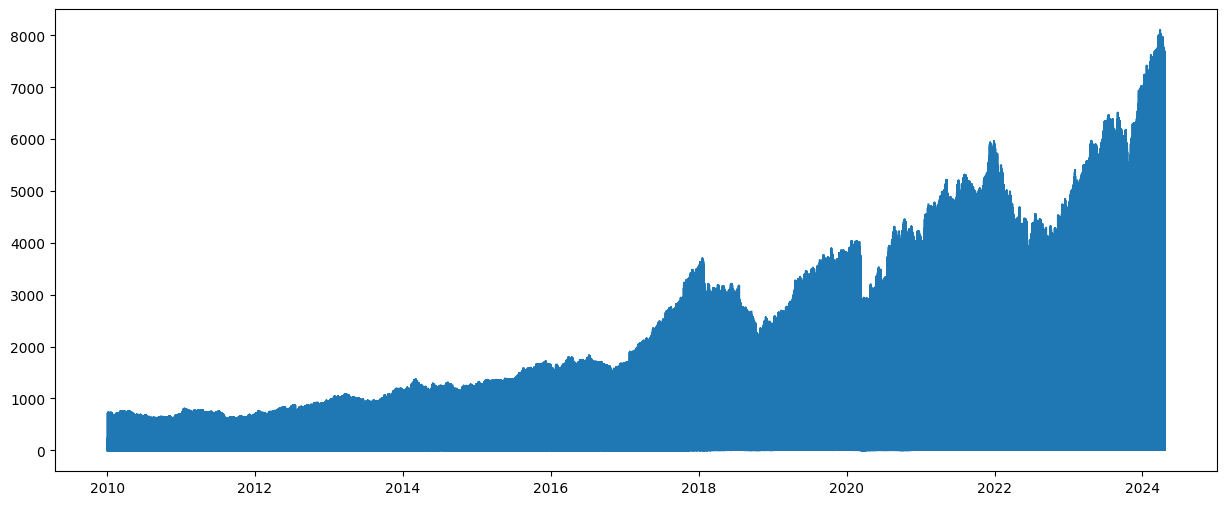

In [29]:
plt.plot(ts)

### Function for testing stationarity

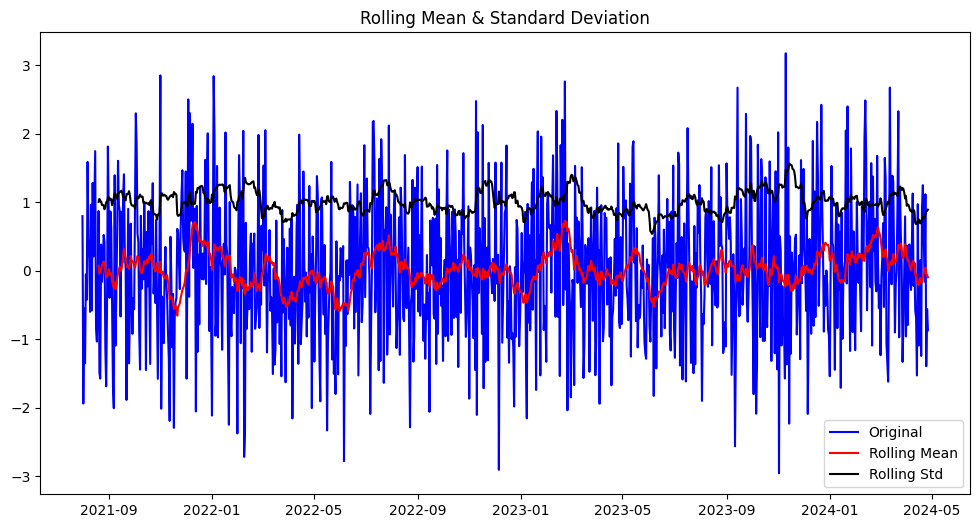

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def test_stationarity(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(window=20).mean()
    rolstd = timeseries.rolling(window=20).std()
    
    # Plot rolling statistics
    plt.figure(figsize=(12, 6))
    orig = plt.plot(timeseries, color='blue', label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

# Example usage:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('8/1/2021', periods=1000))
test_stationarity(ts)


# Making Data Stationary


## Estimating & Eliminating Trend


c:\Users\mohit\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


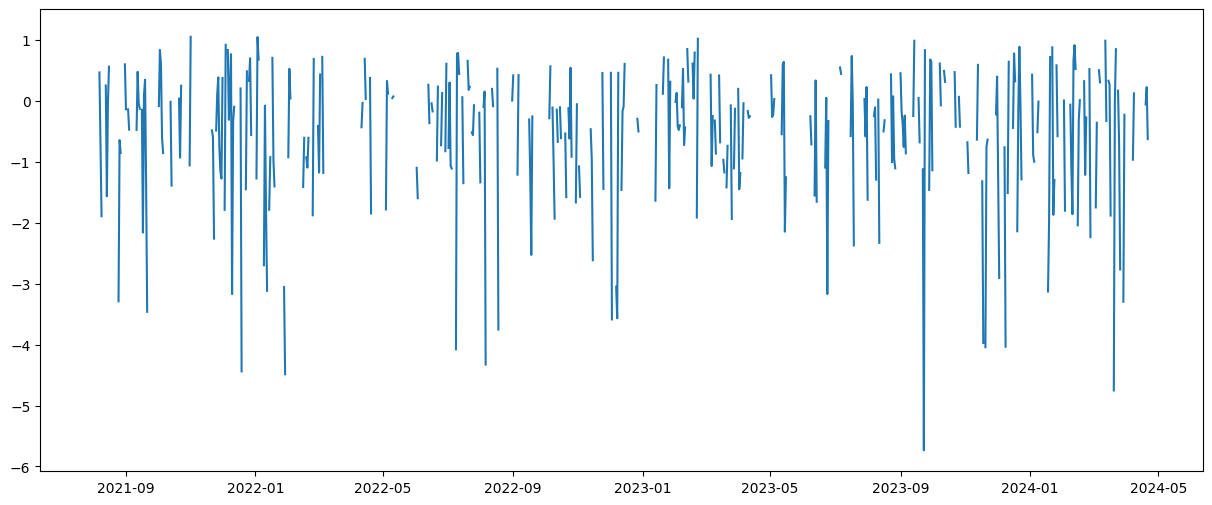

In [31]:
ts_log = np.log(ts)
plt.plot(ts_log)

## Smoothing:

### Moving average

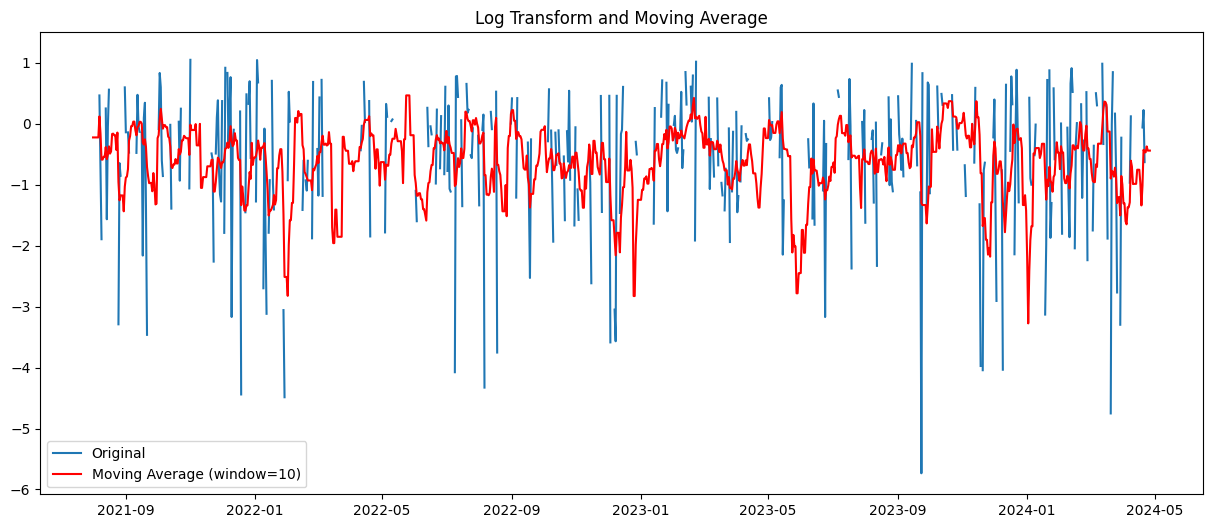

In [32]:
# Calculate the rolling mean
moving_avg = ts_log.rolling(window=10, min_periods=1).mean()

# Plot the original time series and the rolling mean
plt.plot(ts_log, label='Original')
plt.plot(moving_avg, color='red', label='Moving Average (window=10)')
plt.legend()
plt.title('Log Transform and Moving Average')
plt.show()


In [33]:
print(moving_avg)

2021-08-01   -0.224545
2021-08-02   -0.224545
2021-08-03   -0.224545
2021-08-04   -0.224545
2021-08-05   -0.224545
                ...   
2024-04-22   -0.468287
2024-04-23   -0.371540
2024-04-24   -0.440527
2024-04-25   -0.440527
2024-04-26   -0.440527
Freq: D, Length: 1000, dtype: float64


In [34]:
ts_log_moving_avg_diff = ts_log - moving_avg
ts_log_moving_avg_diff.head(15)

2021-08-01    0.000000
2021-08-02         NaN
2021-08-03         NaN
2021-08-04         NaN
2021-08-05         NaN
2021-08-06         NaN
2021-08-07    0.344380
2021-08-08   -0.545872
2021-08-09   -1.305996
2021-08-10         NaN
2021-08-11    0.506034
2021-08-12         NaN
2021-08-13    0.633218
2021-08-14   -0.986858
2021-08-15    0.456740
Freq: D, dtype: float64

In [35]:
ts_log_moving_avg_diff.dropna(inplace=True)
ts_log_moving_avg_diff.head()

2021-08-01    0.000000
2021-08-07    0.344380
2021-08-08   -0.545872
2021-08-09   -1.305996
2021-08-11    0.506034
dtype: float64

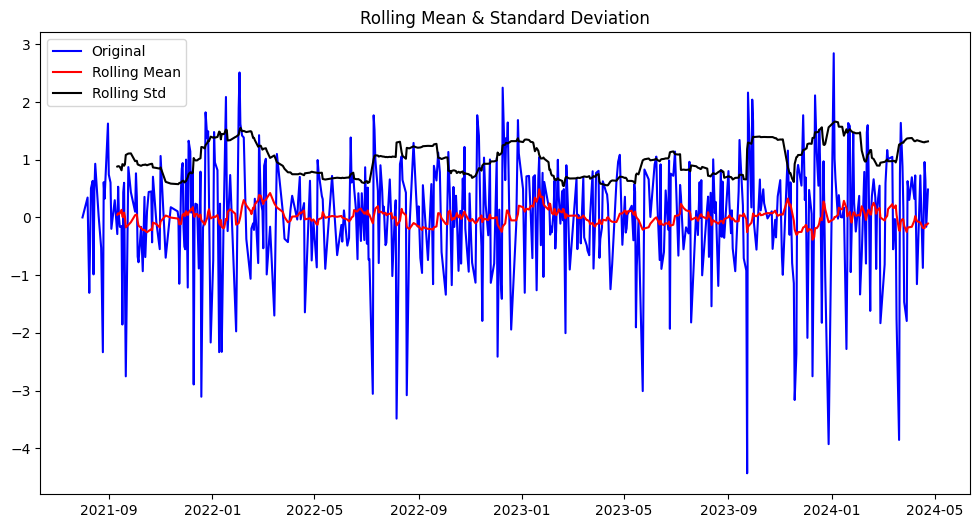

In [36]:
test_stationarity(ts_log_moving_avg_diff)

### Exponentially Weighted Moving Average

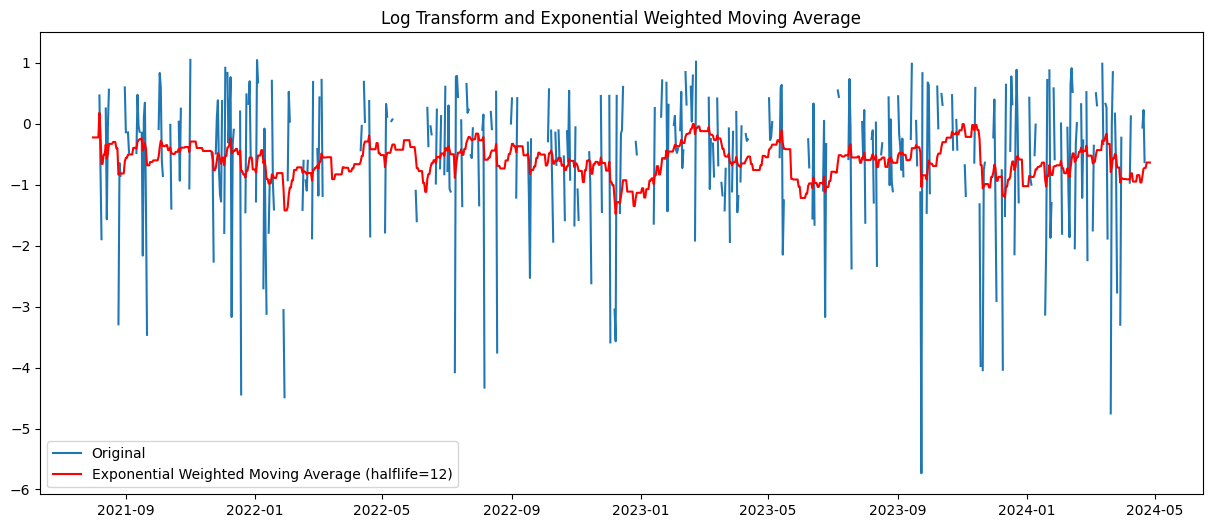

In [37]:
# Calculate the exponentially weighted moving average (EWMA)
expwighted_avg = ts_log.ewm(halflife=12).mean()

# Plot the original time series and the EWMA
plt.plot(ts_log, label='Original')
plt.plot(expwighted_avg, color='red', label='Exponential Weighted Moving Average (halflife=12)')
plt.legend()
plt.title('Log Transform and Exponential Weighted Moving Average')
plt.show()


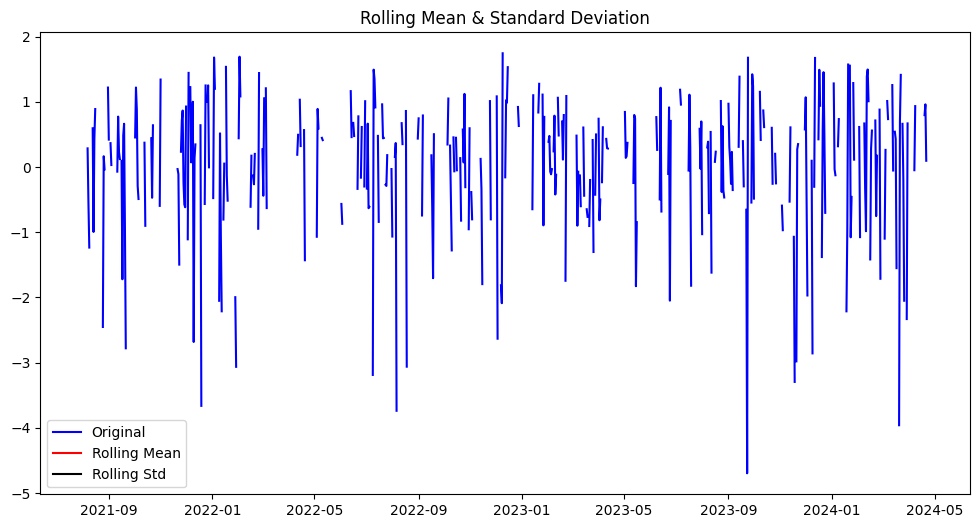

In [38]:
ts_log_ewma_diff = ts_log - expwighted_avg
test_stationarity(ts_log_ewma_diff)

## Eliminating Trend and Seasonality

### Differencing:

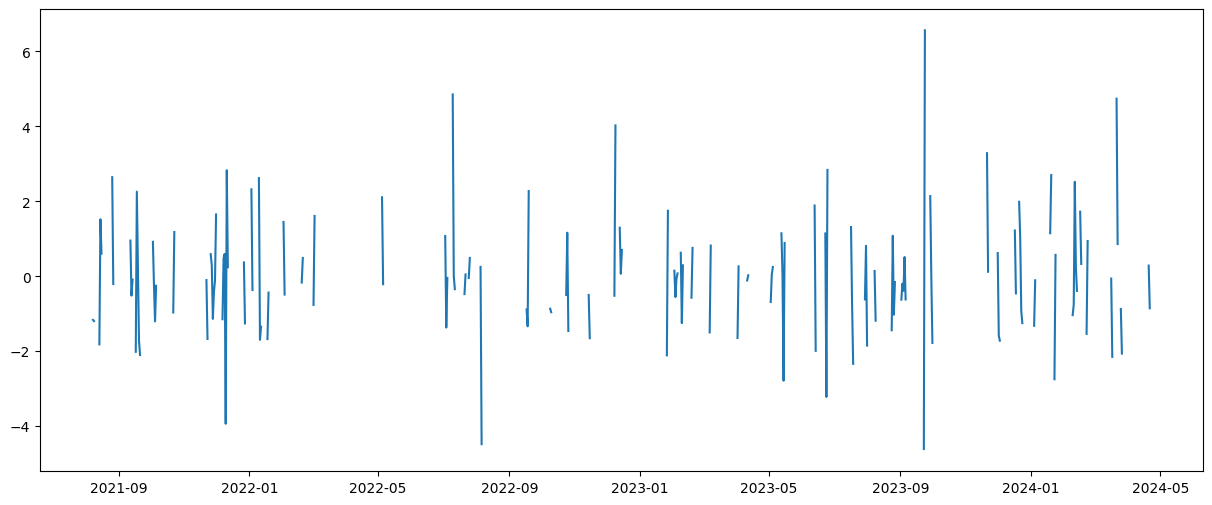

In [39]:
#Take first difference:
ts_log_diff = ts_log - ts_log.shift()
plt.plot(ts_log_diff)

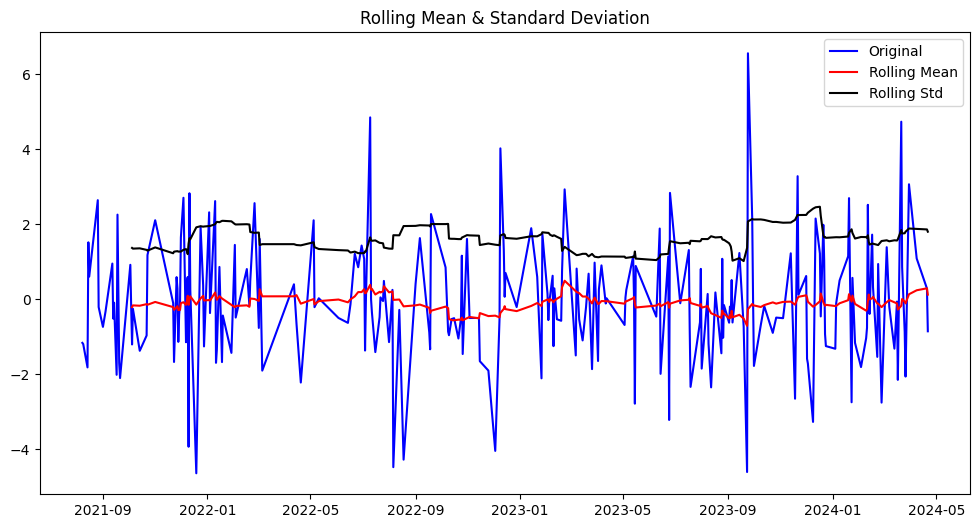

In [40]:
ts_log_diff.dropna(inplace=True)
test_stationarity(ts_log_diff)

# Final Forecasting

In [41]:
from statsmodels.tsa.arima_model import ARIMA

### ACF & PACF Plots

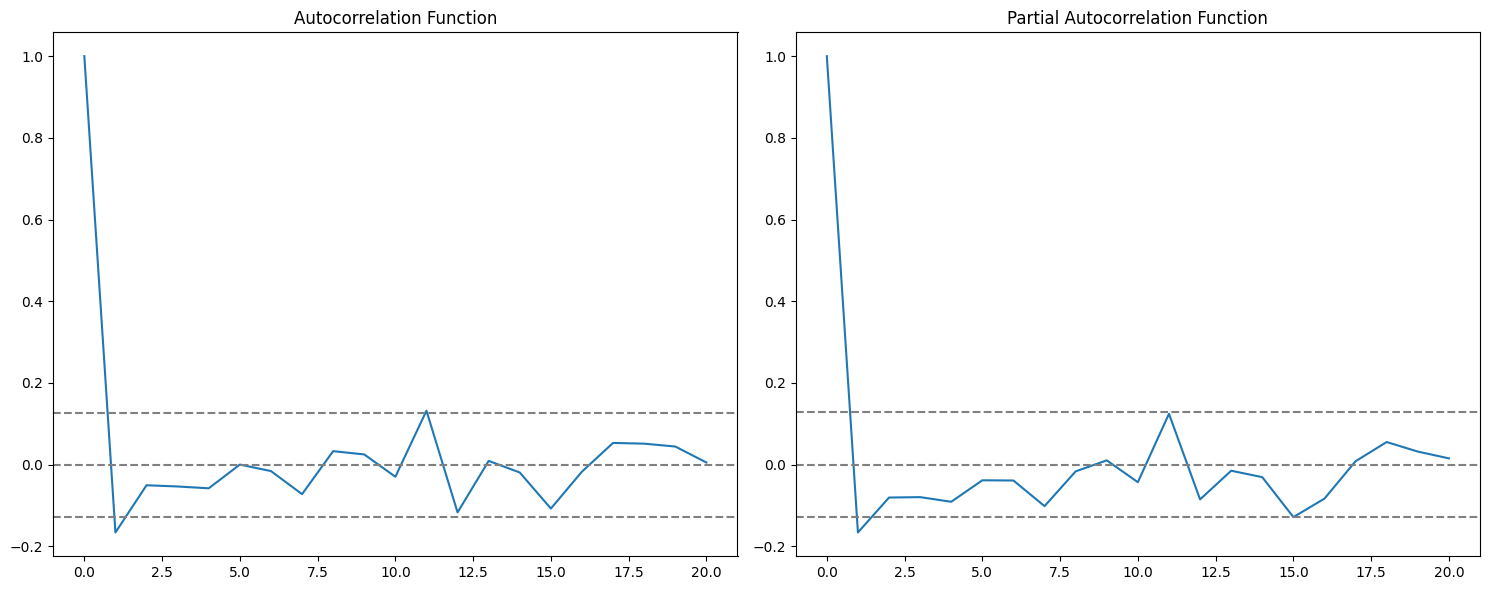

In [42]:
#ACF and PACF plots:
from statsmodels.tsa.stattools import acf, pacf  

lag_acf = acf(ts_log_diff, nlags=20)
lag_pacf = pacf(ts_log_diff, nlags=20, method='ols')

#Plot ACF:    
plt.subplot(121)    
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')

#Plot PACF:
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

### AR Model:

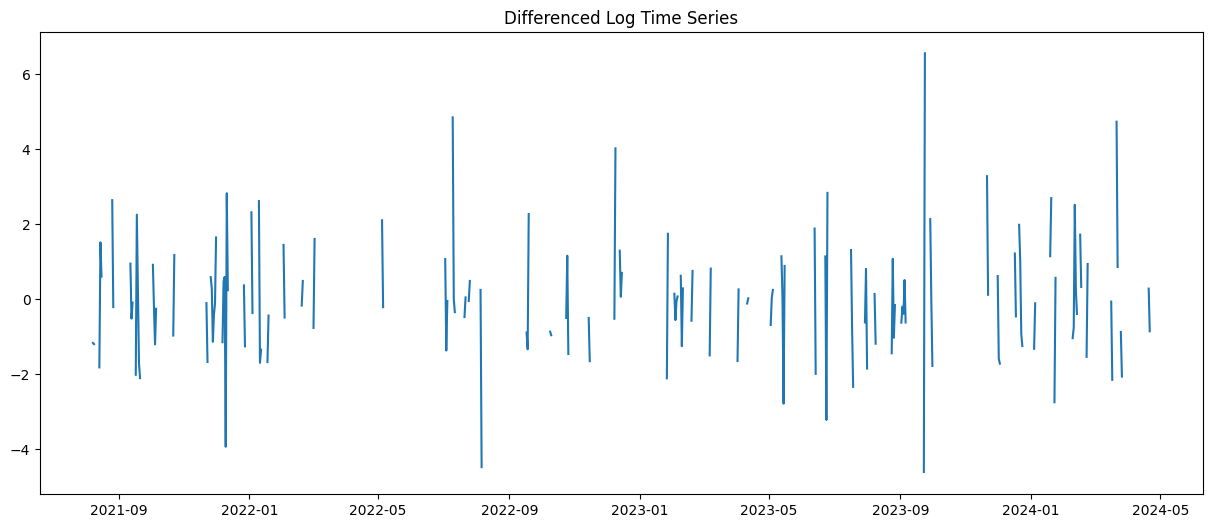

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 1, 0)   Log Likelihood                -836.516
Date:                Sat, 27 Apr 2024   AIC                           1679.033
Time:                        16:45:28   BIC                           1693.753
Sample:                    08-01-2021   HQIC                          1684.628
                         - 04-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8809      0.046    -18.944      0.000      -0.972      -0.790
ar.L2         -0.4948      0.041    -12.021      0.000      -0.575      -0.414
sigma2         1.3704      0.071     19.387      0.0

In [43]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the ARIMA model with order (p, d, q) = (2, 1, 0)
model = ARIMA(ts_log, order=(2, 1, 0))

# Fit the ARIMA model
results_AR = model.fit()

# Plot the differenced log time series (ts_log_diff)
plt.plot(ts_log.diff(), label='Difference of Log Time Series')
plt.title('Differenced Log Time Series')
plt.show()

# Print the summary of the ARIMA model results
print(results_AR.summary())


### MA Model

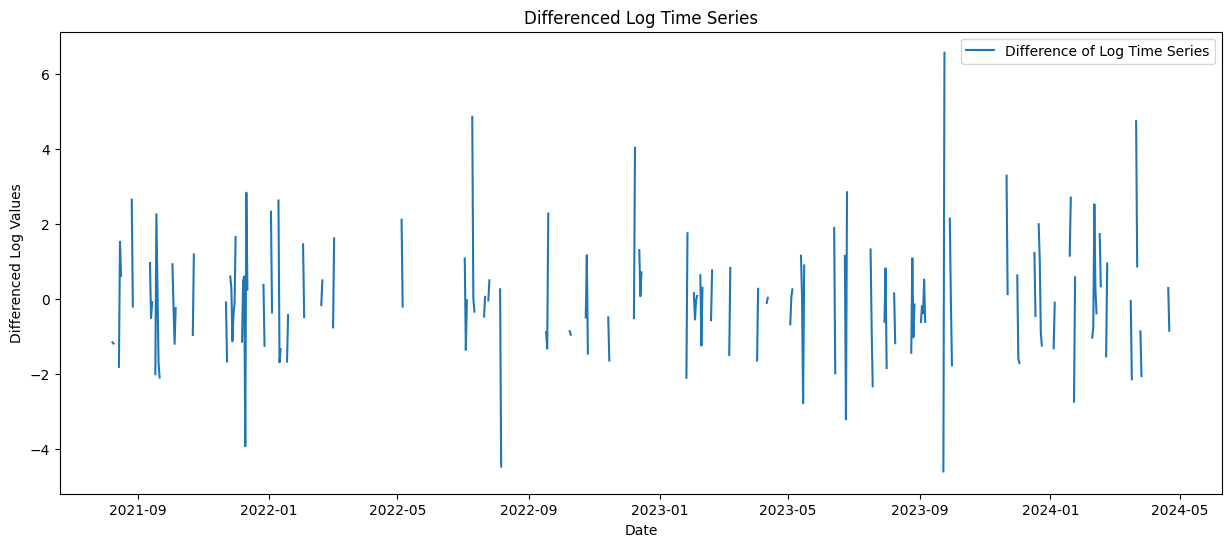

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 1, 0)   Log Likelihood                -836.516
Date:                Sat, 27 Apr 2024   AIC                           1679.033
Time:                        16:45:31   BIC                           1693.753
Sample:                    08-01-2021   HQIC                          1684.628
                         - 04-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8809      0.046    -18.944      0.000      -0.972      -0.790
ar.L2         -0.4948      0.041    -12.021      0.000      -0.575      -0.414
sigma2         1.3704      0.071     19.387      0.0

In [44]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA model with order (p, d, q) = (2, 1, 0)
# - p: autoregressive order
# - d: differencing order
# - q: moving average order
order = (2, 1, 0)
model = ARIMA(ts_log, order=order)

# Fit the ARIMA model
results_AR = model.fit()

# Plot the differenced log time series (ts_log.diff())
ts_log_diff = ts_log.diff()
plt.plot(ts_log_diff, label='Difference of Log Time Series')
plt.title('Differenced Log Time Series')
plt.xlabel('Date')
plt.ylabel('Differenced Log Values')
plt.legend()
plt.show()

# Print the summary of the ARIMA model results
print(results_AR.summary())


### ARIMA Model:

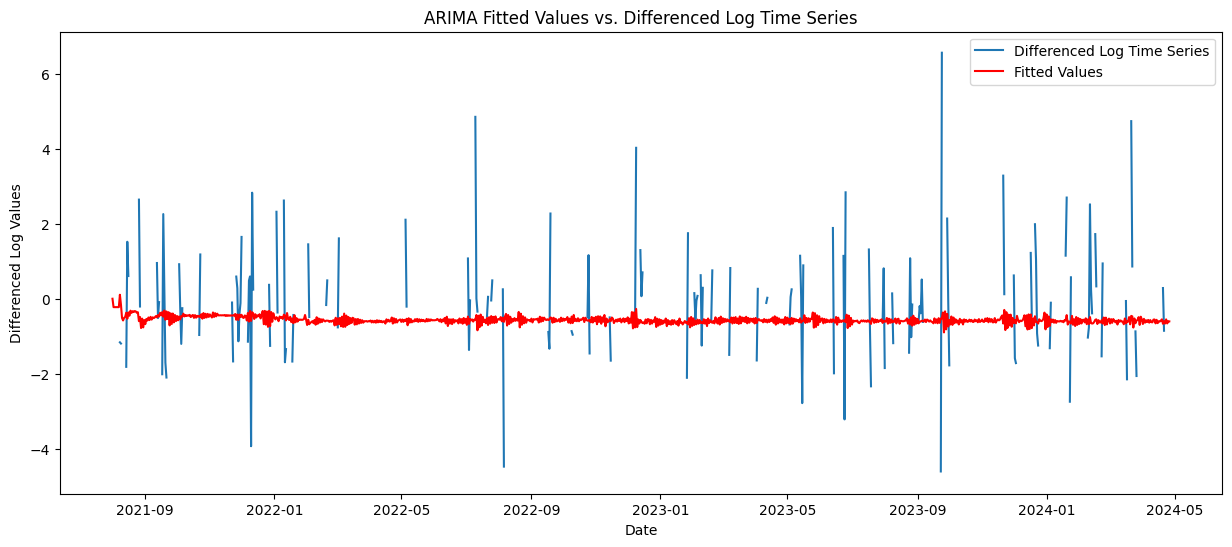

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -759.295
Date:                Sat, 27 Apr 2024   AIC                           1528.591
Time:                        16:45:39   BIC                           1553.125
Sample:                    08-01-2021   HQIC                          1537.916
                         - 04-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9148      0.161     -5.685      0.000      -1.230      -0.599
ar.L2         -0.0632      0.065     -0.968      0.333      -0.191       0.065
ma.L1         -0.0966      0.518     -0.187      0.8

In [45]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA model with order (p, d, q) = (2, 1, 2)
order = (2, 1, 2)
model = ARIMA(ts_log, order=order)

# Fit the ARIMA model
results_ARIMA = model.fit()

# Get the differenced log time series (ts_log_diff)
ts_log_diff = ts_log.diff()

# Plot the original differenced log time series and the fitted values
plt.plot(ts_log_diff, label='Differenced Log Time Series')
plt.plot(results_ARIMA.fittedvalues, color='red', label='Fitted Values')
plt.title('ARIMA Fitted Values vs. Differenced Log Time Series')
plt.xlabel('Date')
plt.ylabel('Differenced Log Values')
plt.legend()
plt.show()

# Print the summary of the ARIMA model results
print(results_ARIMA.summary())


### Convert to original scale:

In [46]:
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
print(predictions_ARIMA_diff.tail())

2024-04-22   -0.662024
2024-04-23   -0.550994
2024-04-24   -0.658746
2024-04-25   -0.598213
2024-04-26   -0.604863
Freq: D, dtype: float64


In [47]:
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print(predictions_ARIMA_diff_cumsum.tail())

2024-04-22   -563.681667
2024-04-23   -564.232661
2024-04-24   -564.891407
2024-04-25   -565.489620
2024-04-26   -566.094483
Freq: D, dtype: float64


In [48]:
# Initialize predictions_ARIMA_log with the first value of ts_log
predictions_ARIMA_log = pd.Series(ts_log.iloc[0], index=ts_log.index)

# Add the cumulative sum of predicted differences to the initial value
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum, fill_value=0)

# Display the first few rows of predictions_ARIMA_log
predictions_ARIMA_log.tail()


2024-04-22   -563.906212
2024-04-23   -564.457205
2024-04-24   -565.115952
2024-04-25   -565.714165
2024-04-26   -566.319028
Freq: D, dtype: float64

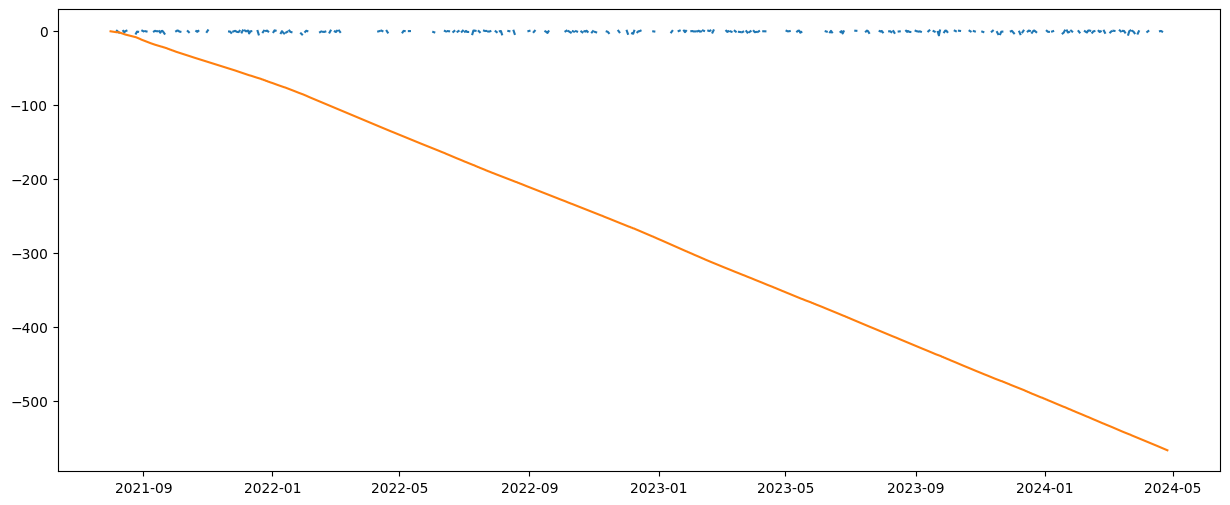

In [49]:
plt.plot(ts_log)
plt.plot(predictions_ARIMA_log)

Text(0.5, 1.0, 'RMSE: 1.0220')

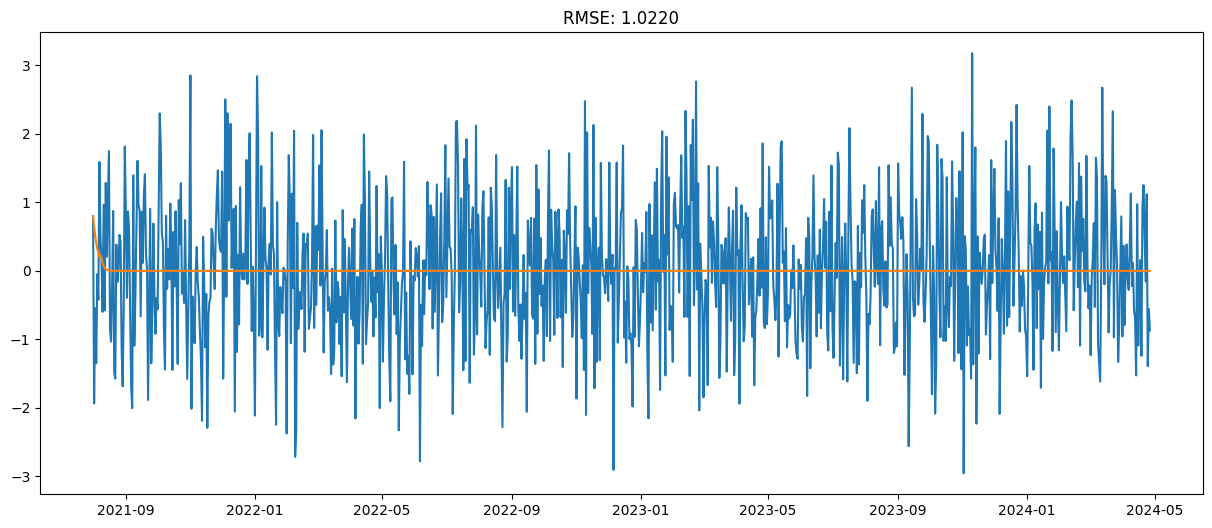

In [50]:
predictions_ARIMA = np.exp(predictions_ARIMA_log)
plt.plot(ts)
plt.plot(predictions_ARIMA)
plt.title('RMSE: %.4f'% np.sqrt(sum((predictions_ARIMA-ts)**2)/len(ts)))

# Data Normalization 

## Standardization (z-score normalization) 

### This method scales the data to have a mean of 0 and a standard deviation of 1.

In [51]:
from sklearn.preprocessing import StandardScaler

# Assuming df is your DataFrame
# Select the numeric columns for normalization
numeric_columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected columns
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])


## Min- Max Scaling

### This method scales the data to a fixed range, typically 0 to 1.

In [52]:
from sklearn.preprocessing import MinMaxScaler

# Assuming df is your DataFrame
# Select the numeric columns for normalization
numeric_columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the selected columns
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])


# Feature Selection

In [53]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [54]:
import pandas as pd

# Assuming 'data' is your DataFrame containing features and target variable
data_cleaned = data.dropna(subset=['Close'])  # Remove rows where 'Close' contains NaN

# Extract features and target variable from cleaned data
X_cleaned = data_cleaned[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y_cleaned = data_cleaned['Close']


In [55]:
from sklearn.impute import SimpleImputer

# Extract the target variable 'y' (assuming 'target' is the column name)
y = data['Close']

# Initialize SimpleImputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Reshape y to 2D array for imputation
y_reshaped = y.values.reshape(-1, 1)

# Fit and transform the imputer on y to replace NaN values
y_imputed = imputer.fit_transform(y_reshaped)

# Reshape y_imputed back to 1D array
y_cleaned = y_imputed.ravel()


In [56]:
import pandas as pd
import numpy as np

# Assuming 'data' is your DataFrame containing features and target variable
data_cleaned = data.dropna(subset=['Close'])  # Remove rows where 'Close' contains NaN

# Extract features and target variable from cleaned data
X_cleaned = data_cleaned[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y_cleaned = data_cleaned['Close']

# Re-align X_cleaned and y_cleaned based on index
X_cleaned.reset_index(drop=True, inplace=True)
y_cleaned.reset_index(drop=True, inplace=True)

# Set the number of top features to select (change as needed)
k = 1

# Perform feature selection on cleaned data
selector = SelectKBest(score_func=f_regression, k=k)
X_selected = selector.fit_transform(X_cleaned, y_cleaned)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_cleaned, test_size=0.2, random_state=42)

# Initialize and train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training R^2 Score:", train_score)
print("Testing R^2 Score:", test_score)


Training R^2 Score: 0.999847860611543
Testing R^2 Score: 0.9998626061199736


# SUPPORT VECTOR MACHINE 

In [57]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

def train_test_svr(df, test_size=0.2):
    # Check for NaN values in the DataFrame
    print("NaN Values in 'open' column:", df['Open'].isnull().sum())
    print("NaN Values in 'close' column:", df['Close'].isnull().sum())
    
    # Handle NaN values (imputation)
    imputer = SimpleImputer(strategy='mean')  # Impute using mean value
    df[['Open', 'Close']] = imputer.fit_transform(df[['Open', 'Close']])
    
    # Extract features (X) and target (y) columns
    X = df[['Open']].values
    y = df['Close'].values
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Initialize SVR model
    svr = SVR(kernel='linear', C=1e3)
    
    # Train SVR model
    svr.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = svr.predict(X_test)
    
    # Calculate mean squared error
    mse = mean_squared_error(y_test, y_pred)
    
    return mse, X_test, y_test, y_pred

# Assuming `data` is your existing DataFrame containing the stock price data
# Make sure your DataFrame has columns 'open' and 'close'
mse, X_test, y_test, y_pred = train_test_svr(data)

# Print Mean Squared Error
print(f"Mean Squared Error: {mse}")


NaN Values in 'open' column: 90677
NaN Values in 'close' column: 90677
Mean Squared Error: 0.007708508449391611


# LSTM AND RNN COMBINED

Epoch 1/50


c:\Users\mohit\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2239 
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1191
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1047
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0985
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0922
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0920
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0848
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0871
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0860
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0823
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0853
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0834
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0870
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0849
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0825
Epoch 16/50
16/16 ━━━━━━━━━━━

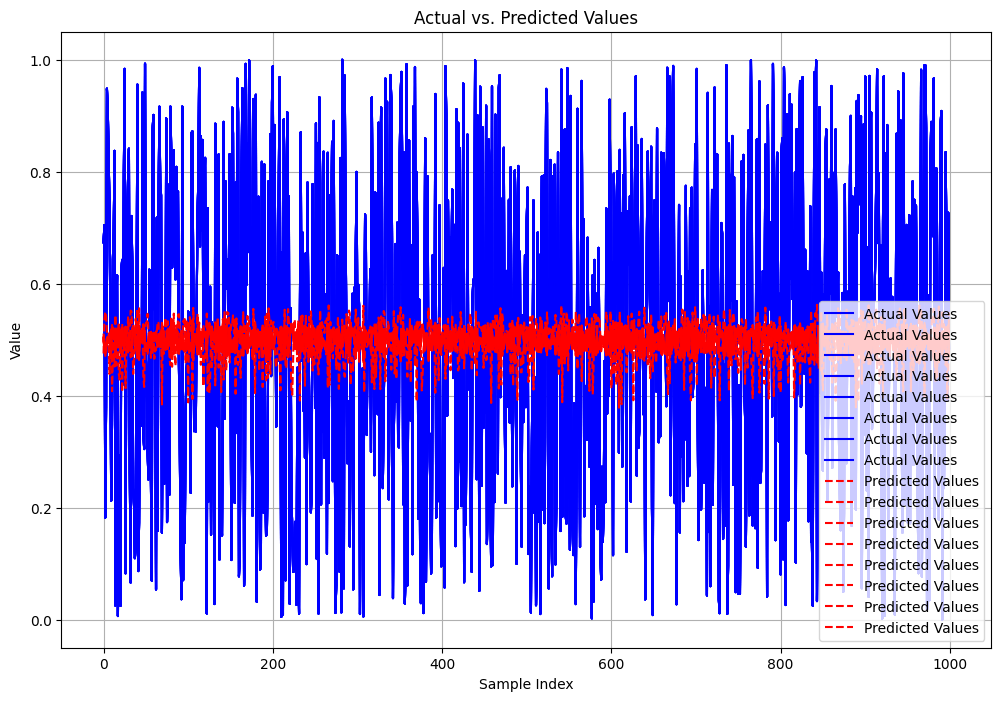

In [66]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, TimeDistributed
from sklearn.metrics import mean_squared_error

# Generate synthetic data for demonstration
data_size = 1000
binary_dim = 8
data = np.random.rand(data_size, 3)  # Example random data

def create_combined_model():
    model = Sequential()
    model.add(SimpleRNN(32, input_shape=(binary_dim, 2), return_sequences=True))
    model.add(LSTM(64, return_sequences=True))
    model.add(TimeDistributed(Dense(1)))
    model.compile(optimizer='adam', loss='mse')
    return model

def train_evaluate_combined_model():
    X = np.zeros((data_size, binary_dim, 2))
    y = np.zeros((data_size, binary_dim, 1))
    
    for i in range(data_size):
        X[i, :, 0] = data[i][0]
        X[i, :, 1] = data[i][1]
        y[i, :, 0] = data[i][2]
    
    model = create_combined_model()
    model.fit(X, y, epochs=50, batch_size=64, verbose=1)
    
    predictions = model.predict(X)
    y_flat = y.reshape(-1)
    predictions_flat = predictions.reshape(-1)
    mse = mean_squared_error(y_flat, predictions_flat)
    
    return predictions, y, mse  # Return original y instead of y_flat

# Train and evaluate the combined RNN-LSTM model
predicted_values, actual_values, mse = train_evaluate_combined_model()
print(f"Combined RNN-LSTM Mean Squared Error (MSE): {mse}")

# Plotting predicted values vs. actual values
plt.figure(figsize=(12, 8))
# Reshape predicted_values to match the shape of actual_values
predicted_values = predicted_values.reshape(-1, binary_dim, 1)
plt.plot(actual_values[:, :, 0], label='Actual Values', color='blue')  # Plot actual values
plt.plot(predicted_values[:, :, 0], label='Predicted Values', color='red', linestyle='--')  # Plot predicted values
plt.title('Actual vs. Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()
# Assuming 'model' is your LSTM and RNN combined model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)




#  ADABOOST REGRESSOR

In [59]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Extract features and target variable from cleaned data
X_cleaned = data_cleaned[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y_cleaned = data_cleaned['Close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Standardize the features (optional but recommended for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


RMSE: 0.006963358922843102
R-squared: 0.923613874981217


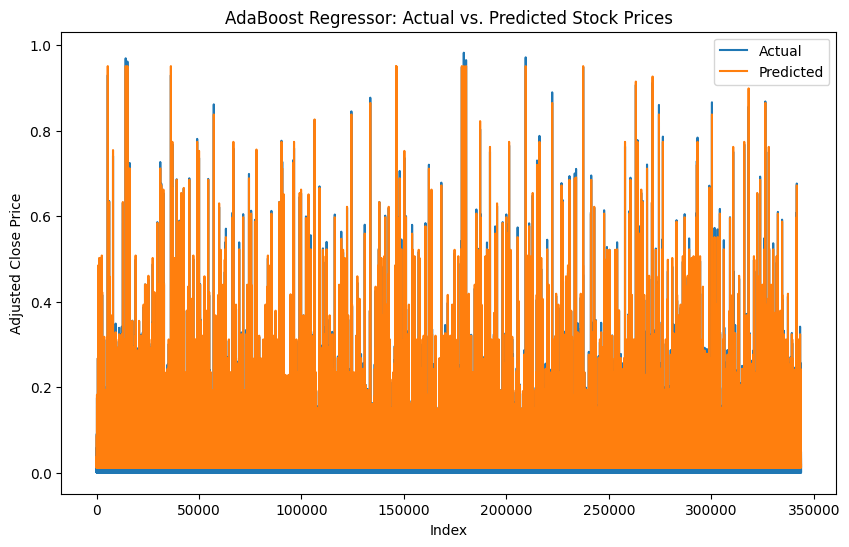

In [67]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Initialize AdaBoostRegressor
adaboost_model = AdaBoostRegressor(n_estimators=50, learning_rate=1.0, random_state=42)

# Train the model
adaboost_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = adaboost_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r_squared = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r_squared}")

# Plot actual vs. predicted prices
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('AdaBoost Regressor: Actual vs. Predicted Stock Prices')
plt.xlabel('Index')
plt.ylabel('Adjusted Close Price')
plt.show()
# Save AdaBoostRegressor model
with open('adaboost_model.pkl', 'wb') as f:
    pickle.dump(adaboost_model, f)


# BAGGING REGRESSOR

In [69]:
import pandas as pd
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Extract features and target variable from cleaned data
X_cleaned = data_cleaned[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y_cleaned = data_cleaned['Close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize BaggingRegressor with default base estimator (DecisionTreeRegressor)
bagging_model = BaggingRegressor(n_estimators=50, random_state=42)

# Train the BaggingRegressor model
bagging_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = bagging_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")
# Save BaggingRegressor model
with open('bagging_model.pkl', 'wb') as f:
    pickle.dump(bagging_model, f)


RMSE: 0.00010905217604877717
R-squared: 0.9999812653497929


# KNN REGRESSOR

In [70]:
import pandas as pd
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Extract features and target variable from cleaned data
X_cleaned = data_cleaned[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y_cleaned = data_cleaned['Close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)  # Adjust n_neighbors as needed

# Train the KNN model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

RMSE: 0.00016480120611281693
R-squared: 0.9999572143939145


# GRADIENT BOOSTING REGRESSOR

In [71]:
import pandas as pd
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming data_cleaned is your preprocessed dataset
# Extract features and target variable from cleaned data
X_cleaned = data_cleaned[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y_cleaned = data_cleaned['Close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Standardize features (if needed)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the Gradient Boosting model
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")
# Save GradientBoostingRegressor model
with open('gb_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)


RMSE: 0.00033814911927228876
R-squared: 0.9998198669352555
